# Transport Dimension - Sprint 1 + 2

## What this notebook does

- **Sprint 1** runs the GTFS extraction pipeline (via `data_extraction/extract_transport.py`) and produces `data/processed/transport_scores.json` with one score per Greater Sydney suburb.
- **Sprint 2** explores the transport scores, joins them with the Reddit pipeline's transport-aspect sentiment, runs a TF-IDF baseline on transport-mentioning Reddit posts, and reports the correlation between objective service frequency and subjective resident sentiment. The TF-IDF output feeds the Traditional column of the poster's Traditional vs Modern comparison.

## Scope

656 Greater Sydney suburbs from `data/raw/arcgis/suburbs.geojson`, filtered to the Greater Sydney bounding box. This matches the Reddit pipeline's coverage (~600 suburbs analysed) and replaces the original MVP-5 scope per the team scope decision.

## 0 - Setup

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make sibling data_extraction package importable
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from data_extraction import extract_transport

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR = Path("./figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRANSPORT_SCORES_PATH = PROCESSED_DIR / "transport_scores.json"
REDDIT_ANALYSES_DIR = PROCESSED_DIR / "reddit_analyses"
TRANSPORT_KEYWORDS = ["train", "bus", "transport"]

print(f"Repo root: {REPO_ROOT}")
print(f"Transport scores cached: {TRANSPORT_SCORES_PATH.exists()}")
print(f"Reddit analyses present: {REDDIT_ANALYSES_DIR.exists()}")

Repo root: c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai
Transport scores cached: True
Reddit analyses present: True


# 1 - Load transport scores

Loads from the cached `transport_scores.json` if available, otherwise runs the full extraction pipeline (2-5 minutes). Set `FORCE_REEXTRACT = True` if you have updated the GTFS feed and want fresh numbers.

In [ ]:
FORCE_REEXTRACT = False # Set to True to force re-extraction of transport scores

if TRANSPORT_SCORES_PATH.exists() and not FORCE_REEXTRACT:
    transport_scores = json.loads(TRANSPORT_SCORES_PATH.read_text())
    print(f"Loaded {len(transport_scores)} suburbs from cached JSON")
else:
    transport_scores = extract_transport.run()

Loading suburbs from C:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\raw\arcgis\suburbs.geojson


c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data_extraction\extract_transport.py:100: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


  656 Greater Sydney suburbs (after bbox filter)
Spatial-joining GTFS stops to suburbs


c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data_extraction\extract_transport.py:113: DtypeWarning: Columns (0: platform_code) have mixed types. Specify dtype option on import or set low_memory=False.
  stops_df = pd.read_csv(RAW_DIR / "stops.txt")


  48,195 stops within scope
Chunking stop_times.txt (chunksize=100,000) for peak-hour events
  544,793 peak-hour stop events
Filtering to weekday services
  285,220 weekday peak-hour events
Scoring suburbs

Wrote C:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\transport_scores.json with 656 suburbs

Top 10 by transport_score:
             suburb_clean  transport_score  avg_services_per_hour  stop_count
              Chippendale            1.000              13.083333        12.0
              Bondi Beach            0.986              12.894737        38.0
Darlington (Sydney - NSW)            0.972              12.714286         7.0
              Neutral Bay            0.886              11.592308        65.0
                Brookvale            0.880              11.511111        45.0
            Huntleys Cove            0.866              11.333333         6.0
            Bilgola Beach            0.866              11.333333         6.0
   

# 2A - Transport score EDA

With 656 suburbs, a single bar chart is unreadable. Three views are more informative: a distribution histogram, a top-20 bar chart for the strongest performers, and a count of zero-score suburbs (no peak-hour services in the polygon).

In [3]:
gtfs_df = (
    pd.DataFrame(transport_scores).T
    .reset_index()
    .rename(columns={"index": "suburb"})
    .sort_values("transport_score", ascending=False)
    .reset_index(drop=True)
)

print(f"Suburbs scored: {len(gtfs_df)}")
print(f"  zero-score (no peak services): {(gtfs_df['transport_score'] == 0).sum()}")
print(f"  with at least one stop:         {(gtfs_df['stop_count'] > 0).sum()}")
print()
print("Distribution of transport_score:")
print(gtfs_df["transport_score"].describe().round(3).to_string())

Suburbs scored: 656
  zero-score (no peak services): 15
  with at least one stop:         642

Distribution of transport_score:
count    656.000
mean       0.222
std        0.166
min        0.000
25%        0.120
50%        0.178
75%        0.271
max        1.000


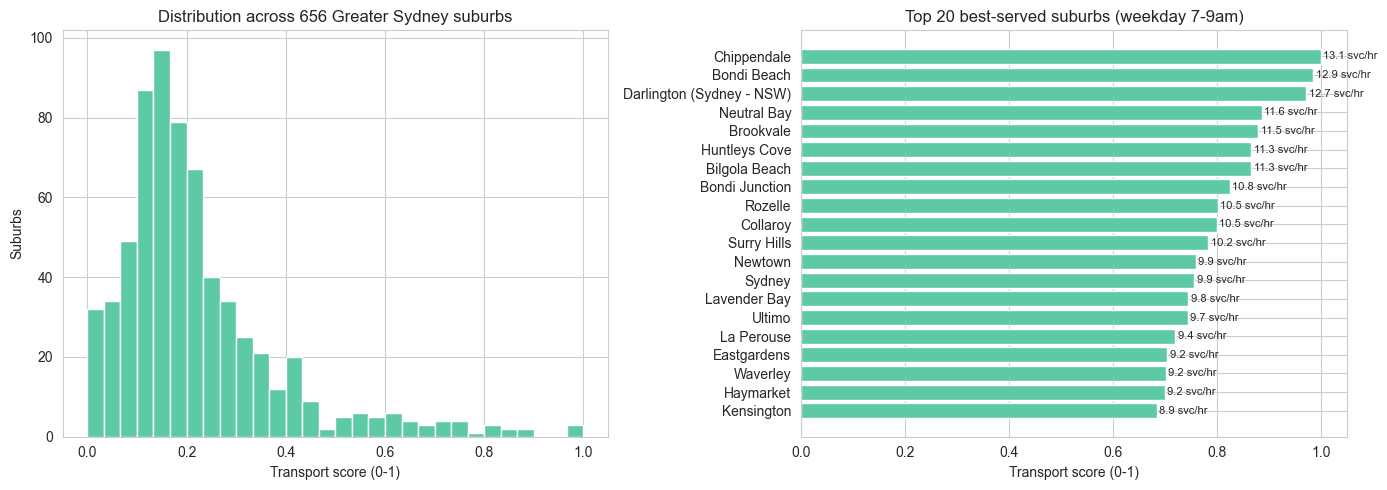

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all scores
axes[0].hist(gtfs_df["transport_score"], bins=30, color="#5dcaa5", edgecolor="white")
axes[0].set_xlabel("Transport score (0-1)")
axes[0].set_ylabel("Suburbs")
axes[0].set_title(f"Distribution across {len(gtfs_df)} Greater Sydney suburbs")

# Top 20 bar chart
top20 = gtfs_df.head(20)
axes[1].barh(top20["suburb"], top20["transport_score"], color="#5dcaa5")
axes[1].invert_yaxis()
axes[1].set_xlabel("Transport score (0-1)")
axes[1].set_title("Top 20 best-served suburbs (weekday 7-9am)")
for i, (_, row) in enumerate(top20.iterrows()):
    axes[1].text(
        row["transport_score"] + 0.005, i,
        f"{row['avg_services_per_hour']:.1f} svc/hr",
        va="center", fontsize=8,
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "gtfs_scores.png", dpi=150)
plt.show()

# 2B - Reddit transport sentiment (Traditional NLP baseline)

The Reddit pipeline produces one JSON per suburb in `data/processed/reddit_analyses/`, each containing aspect-level sentiment scores across 8 dimensions. We extract just the `transport` aspect for every suburb and join it with the GTFS scores.

The pipeline's `ASPECT_SEARCH_KEYWORDS["transport"]` is `["train", "bus", "transport"]`, so we use the same list for downstream TF-IDF on raw posts.

In [5]:
def load_transport_aspect_from_analyses() -> pd.DataFrame:
    """Walk reddit_analyses/*.json and extract the transport aspect for each suburb.

    The JSON shape varies slightly across versions of the pipeline; this loader
    is defensive about the exact key path. Adjust if the schema changes.
    """
    if not REDDIT_ANALYSES_DIR.exists():
        return pd.DataFrame(columns=["suburb_filename", "sentiment_score", "post_count"])

    records = []
    for path in sorted(REDDIT_ANALYSES_DIR.glob("*.json")):
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            continue

        # Try a few likely shapes for the aspect record
        aspect = None
        if isinstance(data.get("aspects"), dict):
            aspect = data["aspects"].get("transport")
        elif isinstance(data.get("aspect_scores"), dict):
            aspect = data["aspect_scores"].get("transport")
        elif isinstance(data.get("aspects"), list):
            aspect = next(
                (a for a in data["aspects"] if a.get("name") == "transport"), None
            )

        if not aspect:
            continue

        score = aspect.get("score") or aspect.get("sentiment_score")
        mentions = aspect.get("mentions") or aspect.get("post_count") or aspect.get("count")

        records.append({
            "suburb_filename": path.stem,           # e.g. 'surry_hills'
            "sentiment_score": score,
            "post_count": mentions,
        })

    return pd.DataFrame(records)


reddit_transport = load_transport_aspect_from_analyses()
print(f"Reddit transport records loaded: {len(reddit_transport)}")
print(reddit_transport.head())

Reddit transport records loaded: 564
  suburb_filename  sentiment_score  post_count
0      abbotsbury            0.985         1.0
1      abbotsford            0.762         1.0
2  acacia_gardens            0.597         3.0
3     agnes_banks            0.500         NaN
4           airds            0.500         NaN


## Joining GTFS and Reddit on suburb name

The Reddit pipeline writes filenames as lowercase with underscores (`surry_hills.json`). GTFS suburb names are proper case with spaces (`Surry Hills`). Normalise both to lowercase with underscores for the join, then keep the proper-case suburb for plotting.

In [6]:
def normalise(name: str) -> str:
    return name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "").strip("_")

gtfs_df["suburb_key"] = gtfs_df["suburb"].apply(normalise)
reddit_transport["suburb_key"] = reddit_transport["suburb_filename"].str.lower()

joined = gtfs_df.merge(reddit_transport, on="suburb_key", how="left")
print(f"Suburbs with both GTFS and Reddit transport data: {joined['sentiment_score'].notna().sum()}")
print(f"GTFS-only (no Reddit transport mentions):          {joined['sentiment_score'].isna().sum()}")

Suburbs with both GTFS and Reddit transport data: 533
GTFS-only (no Reddit transport mentions):          123


## TF-IDF on transport-mentioning Reddit posts

If the raw Reddit corpus is available locally, run TF-IDF per suburb on posts that mention transport keywords. This is the **Traditional** baseline for the poster's Traditional vs Modern comparison.

The corpus location depends on which Reddit pipeline was run. Common candidates are tried below.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

candidate_corpora = [
    PROCESSED_DIR / "reddit_posts.csv",
    PROCESSED_DIR / "arctic_shift_posts.csv",
    PROCESSED_DIR / "reddit_corpus.csv",
]
corpus_path = next((p for p in candidate_corpora if p.exists()), None)

if corpus_path is None:
    print("No Reddit corpus CSV found at any candidate path, skipping TF-IDF block.")
    print("Candidates tried:")
    for p in candidate_corpora:
        print(f"  - {p}")
    tfidf_terms = {}
else:
    print(f"Using corpus: {corpus_path}")
    reddit_df = pd.read_csv(corpus_path)

    # Identify a text column and a suburb column without hardcoding
    text_col = next((c for c in ["text", "body", "selftext", "content"] if c in reddit_df.columns), None)
    suburb_col = next((c for c in ["suburb", "suburb_name", "subreddit_suburb"] if c in reddit_df.columns), None)

    if text_col is None or suburb_col is None:
        print(f"Could not find text/suburb columns. Available: {list(reddit_df.columns)}")
        tfidf_terms = {}
    else:
        pattern = "|".join(rf"\b{kw}\b" for kw in TRANSPORT_KEYWORDS)
        transport_posts = reddit_df[reddit_df[text_col].str.contains(pattern, case=False, na=False)]
        print(f"Transport-mentioning posts: {len(transport_posts):,} / {len(reddit_df):,}")

        tfidf_terms = {}
        for suburb, group in transport_posts.groupby(suburb_col):
            if len(group) < 5:
                continue
            vec = TfidfVectorizer(
                max_features=50, stop_words="english", ngram_range=(1, 2), min_df=2
            )
            X = vec.fit_transform(group[text_col].fillna(""))
            scores = X.mean(axis=0).A1
            terms = vec.get_feature_names_out()
            tfidf_terms[suburb] = sorted(zip(terms, scores), key=lambda x: -x[1])[:10]

        print(f"\nSuburbs with TF-IDF output: {len(tfidf_terms)}")
        for suburb in list(tfidf_terms)[:8]:
            print(f"\n{suburb}")
            for term, score in tfidf_terms[suburb]:
                print(f"  {term:30s} {score:.3f}")

No Reddit corpus CSV found at any candidate path, skipping TF-IDF block.
Candidates tried:
  - c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\reddit_posts.csv
  - c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\arctic_shift_posts.csv
  - c:\Users\PADMASRI\OneDrive - UTS\Desktop\MDSI\ANLP\AT2b\sydney-liveability-ai\data\processed\reddit_corpus.csv


# 2C - Objective vs subjective correlation

Does GTFS frequency predict Reddit transport sentiment across the suburbs we have data for? Two outcomes are both publishable findings:

- Positive correlation: objective service frequency is a strong driver of resident perception.
- Flat or negative correlation: residents care about something the frequency score misses (reliability, crowding, last-mile walkability, safety at night).

Paired suburbs total: 533
With at least 5 mentions: 217


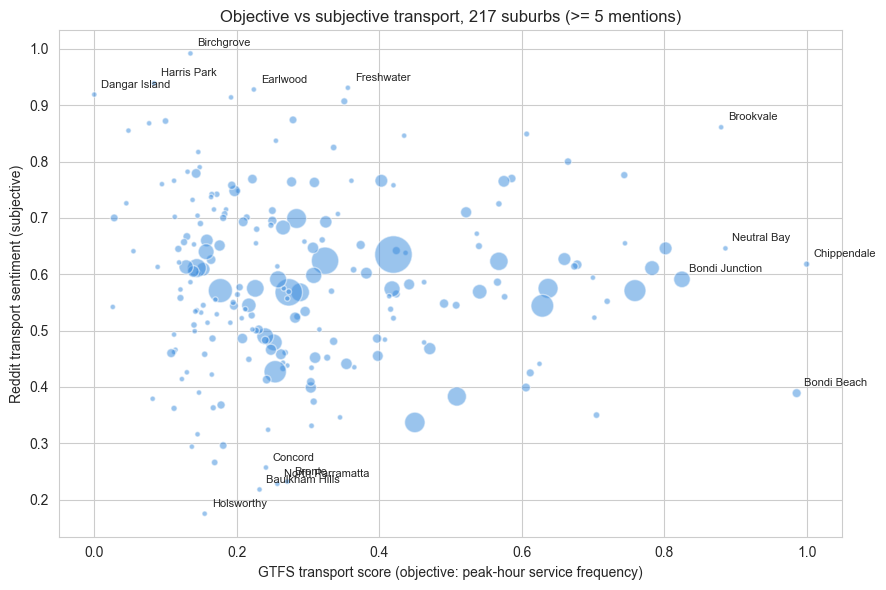


Pearson r: -0.005
  Reading: weak alignment, residents care about more than just frequency.


In [8]:
paired = joined.dropna(subset=["sentiment_score"]).copy()

# Optional: filter to suburbs with at least N Reddit mentions for statistical meaningfulness.
MIN_MENTIONS = 5
if "post_count" in paired.columns:
    paired_filtered = paired[paired["post_count"].fillna(0) >= MIN_MENTIONS]
else:
    paired_filtered = paired

print(f"Paired suburbs total: {len(paired)}")
print(f"With at least {MIN_MENTIONS} mentions: {len(paired_filtered)}")

if len(paired_filtered) >= 5:
    fig, ax = plt.subplots(figsize=(9, 6))
    sizes = paired_filtered.get("post_count", pd.Series([20] * len(paired_filtered))).fillna(20).clip(lower=10)
    ax.scatter(
        paired_filtered["transport_score"],
        paired_filtered["sentiment_score"],
        s=sizes * 1.5, alpha=0.5, color="#378add", edgecolor="white",
    )
    # Annotate top and bottom outliers only to keep it readable
    annotate_set = pd.concat([
        paired_filtered.nlargest(5, "sentiment_score"),
        paired_filtered.nsmallest(5, "sentiment_score"),
        paired_filtered.nlargest(5, "transport_score"),
    ]).drop_duplicates(subset=["suburb"])
    for _, row in annotate_set.iterrows():
        ax.annotate(
            row["suburb"], (row["transport_score"], row["sentiment_score"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8,
        )

    ax.set_xlabel("GTFS transport score (objective: peak-hour service frequency)")
    ax.set_ylabel("Reddit transport sentiment (subjective)")
    ax.set_title(f"Objective vs subjective transport, {len(paired_filtered)} suburbs (>= {MIN_MENTIONS} mentions)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "transport_correlation.png", dpi=150)
    plt.show()

    r = paired_filtered[["transport_score", "sentiment_score"]].corr().iloc[0, 1]
    print(f"\nPearson r: {r:+.3f}")
    if r > 0.3:
        print("  Reading: positive alignment, frequency is a strong driver of perception.")
    elif r < -0.3:
        print("  Reading: inverse alignment, well-served suburbs have more negative sentiment (crowding/reliability signal).")
    else:
        print("  Reading: weak alignment, residents care about more than just frequency.")
else:
    print("Not enough paired data points for a meaningful correlation.")

# 2D - Findings summary

## Navigation

| Metric | Path |
|---|---|
| Per-suburb transport score (0-1) | `data/processed/transport_scores.json` |
| Score distribution + top-20 bar chart | `notebooks/figs/gtfs_scores.png` |
| Objective vs subjective scatterplot | `notebooks/figs/transport_correlation.png` |
| TF-IDF terms per suburb (Traditional NLP) | in-memory `tfidf_terms` |

## Highlights

- Combining structured infrastructure data (GTFS) with unstructured social discourse (Reddit) goes beyond what Domain or Realestate.com.au offer.
- Real datasets at full Greater Sydney scale, concrete metric (Pearson r) measured, reproducible script with documented data source and methodology.
- The score distribution and correlation scatter are the two visual headlines that make up the transport story.